# 🤖 XGBoost Machine Learning Report: Dự Đoán `remain_session_volatility`

## 📌 Mục Tiêu Phân Tích & Bối Cảnh
Notebook này thực hiện huấn luyện, phân tích hiệu năng và dự đoán mục tiêu **`remain_session_volatility`** (Độ biến động giá phần còn lại của phiên) cho hợp đồng tương lai VN30F1M khung 5 phút.

### 🔍 Giải thích sự khác biệt với báo cáo ban đầu (`report.md`):
Báo cáo `report.md` ban đầu đạt chỉ số $R^2 \approx 0.69 - 0.75$ do sử dụng phương pháp **Random Shuffle Split** trên 20,000 mẫu ngẫu nhiên (dẫn đến rò rỉ dữ liệu chuỗi thời gian giữa các nến 5 phút sát nhau). Notebook này cung cấp phân tích đối sánh toàn diện giữa 2 phương pháp phân tách:

1. **Random Shuffle Split (80/20)**: Tái lập kết quả báo cáo ban đầu `report.md`.
2. **Time-Series Chronological Split (80/20)**: Đánh giá thực tế không rò rỉ dữ liệu (Out-of-Time) cho giao dịch thuật toán.

### 🎯 So sánh 2 tập đặc trưng:
- **All Features (~658 features)** vs **Top 20 Features** quan trọng nhất.


In [1]:
# 1. Khai Báo Thư Viện & Cấu Hình Môi Trường
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print('✔ Thư viện ML & Viz đã được tải thành công!')

✔ Thư viện ML & Viz đã được tải thành công!


In [2]:
# 2. Tải & Tiền Xử Lý Dữ Liệu
feature_path = '/home/v002353/Desktop/SN/04. TPO/fl-data-profiler/datasets/feature.parquet'
label_path = '/home/v002353/Desktop/SN/04. TPO/fl-data-profiler/datasets/label.csv'

print('⏳ Đang tải tập dữ liệu Feature Parquet & Label CSV...')
features = pd.read_parquet(feature_path)
labels = pd.read_csv(label_path)

if 'Date' in features.columns:
    features['Date'] = pd.to_datetime(features['Date'])
    labels['Date'] = pd.to_datetime(labels['Date'])
    df = pd.merge(features, labels, on='Date', how='inner')
else:
    features.index = pd.to_datetime(features.index)
    labels['Date'] = pd.to_datetime(labels['Date'])
    df = features.merge(labels, left_index=True, right_on='Date', how='inner')

target_col = 'remain_session_volatility'
df_clean = df.dropna(subset=[target_col]).copy()
print(f'✔ Kích thước Dataset hợp lệ cho `{target_col}`: {df_clean.shape[0]:,} dòng, {df_clean.shape[1]:,} cột.')

# Tách y và X
all_label_cols = ['allow_entry', 'remain_session_volatility', 'remain_session_net_move', 
                  'long_mae', 'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short', 
                  'eod_return_long', 'eod_return_short', 'price_range', 'intraday_position', 'price_shape']
drop_metadata = ['Date', 'trade_date', 'session_start_time', 'session_end_time']
drop_cols = [c for c in all_label_cols if c in df_clean.columns] + [c for c in drop_metadata if c in df_clean.columns]

y = df_clean[target_col]
X_raw = df_clean.drop(columns=drop_cols, errors='ignore')

numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
X = X_raw[numeric_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
nan_ratio = X.isnull().mean()
valid_features = nan_ratio[nan_ratio < 0.5].index.tolist()
X = X[valid_features].fillna(X.median())

print(f'✔ Số đặc trưng kỹ thuật hợp lệ: {X.shape[1]:,}')

⏳ Đang tải tập dữ liệu Feature Parquet & Label CSV...


✔ Kích thước Dataset hợp lệ cho `remain_session_volatility`: 91,866 dòng, 809 cột.


✔ Số đặc trưng kỹ thuật hợp lệ: 658


## 🔀 Phần 1: Tái Lập Kết Quả `report.md` Ban Đầu (Random Shuffle Split)
Sử dụng phân tách ngẫu nhiên `train_test_split(..., test_size=0.2, random_state=42)` giống như trong module `fldataprofier/modules/xgboost.py`.

In [3]:
# 3. Random Shuffle Split (Replicating report.md)
# Lấy mẫu 20,000 mẫu ngẫu nhiên để đối chiếu chính xác với report.md
df_sample_20k = df_clean.sample(n=min(20000, len(df_clean)), random_state=42)
y_sample = df_sample_20k[target_col]
X_sample = df_sample_20k[numeric_cols].replace([np.inf, -np.inf], np.nan)[valid_features].fillna(X.median())

x_tr_rand, x_te_rand, y_tr_rand, y_te_rand = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

model_rand = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)
model_rand.fit(x_tr_rand, y_tr_rand)

p_tr_rand = model_rand.predict(x_tr_rand)
p_te_rand = model_rand.predict(x_te_rand)

r2_tr_rand = r2_score(y_tr_rand, p_tr_rand)
r2_te_rand = r2_score(y_te_rand, p_te_rand)
mae_rand = mean_absolute_error(y_te_rand, p_te_rand)
rmse_rand = np.sqrt(mean_squared_error(y_te_rand, p_te_rand))

print('='*60)
print(f'📌 Random Shuffle Split (reproducing report.md) for `{target_col}`:')
print(f'   Train R2 : {r2_tr_rand:.4f}')
print(f'   Test R2  : {r2_te_rand:.4f}  <-- Khớp hoàn toàn với report.md!')
print(f'   Test MAE : {mae_rand:.4f}')
print(f'   Test RMSE: {rmse_rand:.4f}')
print('='*60)

📌 Random Shuffle Split (reproducing report.md) for `remain_session_volatility`:
   Train R2 : 0.7634
   Test R2  : 0.6945  <-- Khớp hoàn toàn với report.md!
   Test MAE : 4.3276
   Test RMSE: 6.8534


## ⏱️ Phần 2: Đánh Giá Thực Tế Không Rò Rỉ Dữ Liệu (Chronological Time-Series Split)
Sử dụng 80% dữ liệu quá khứ để Train và 20% dữ liệu tương lai để Test (không tráo đổi ngẫu nhiên). So sánh **All Features** vs **Top 20 Features**.

In [4]:
# 4. Time-Series Chronological Split (All Features)
split_idx = int(len(X) * 0.8)
X_train_ts, X_test_ts = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_ts, y_test_ts = y.iloc[:split_idx], y.iloc[split_idx:]

model_ts_all = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_ts_all.fit(X_train_ts, y_train_ts)

p_tr_ts_all = model_ts_all.predict(X_train_ts)
p_te_ts_all = model_ts_all.predict(X_test_ts)

r2_tr_ts_all = r2_score(y_train_ts, p_tr_ts_all)
r2_te_ts_all = r2_score(y_test_ts, p_te_ts_all)
mae_ts_all = mean_absolute_error(y_test_ts, p_te_ts_all)
rmse_ts_all = np.sqrt(mean_squared_error(y_test_ts, p_te_ts_all))
gap_ts_all = r2_tr_ts_all - r2_te_ts_all

print('='*60)
print(f'📌 Time-Series Split (All Features) for `{target_col}`:')
print(f'   Train R2 : {r2_tr_ts_all:.4f}')
print(f'   Test R2  : {r2_te_ts_all:.4f}')
print(f'   Test MAE : {mae_ts_all:.4f}')
print(f'   Test RMSE: {rmse_ts_all:.4f}')
print(f'   Overfit Gap: {gap_ts_all:.4f}')
print('='*60)

📌 Time-Series Split (All Features) for `remain_session_volatility`:
   Train R2 : 0.7992
   Test R2  : 0.2506
   Test MAE : 9.6134
   Test RMSE: 13.7944
   Overfit Gap: 0.5486


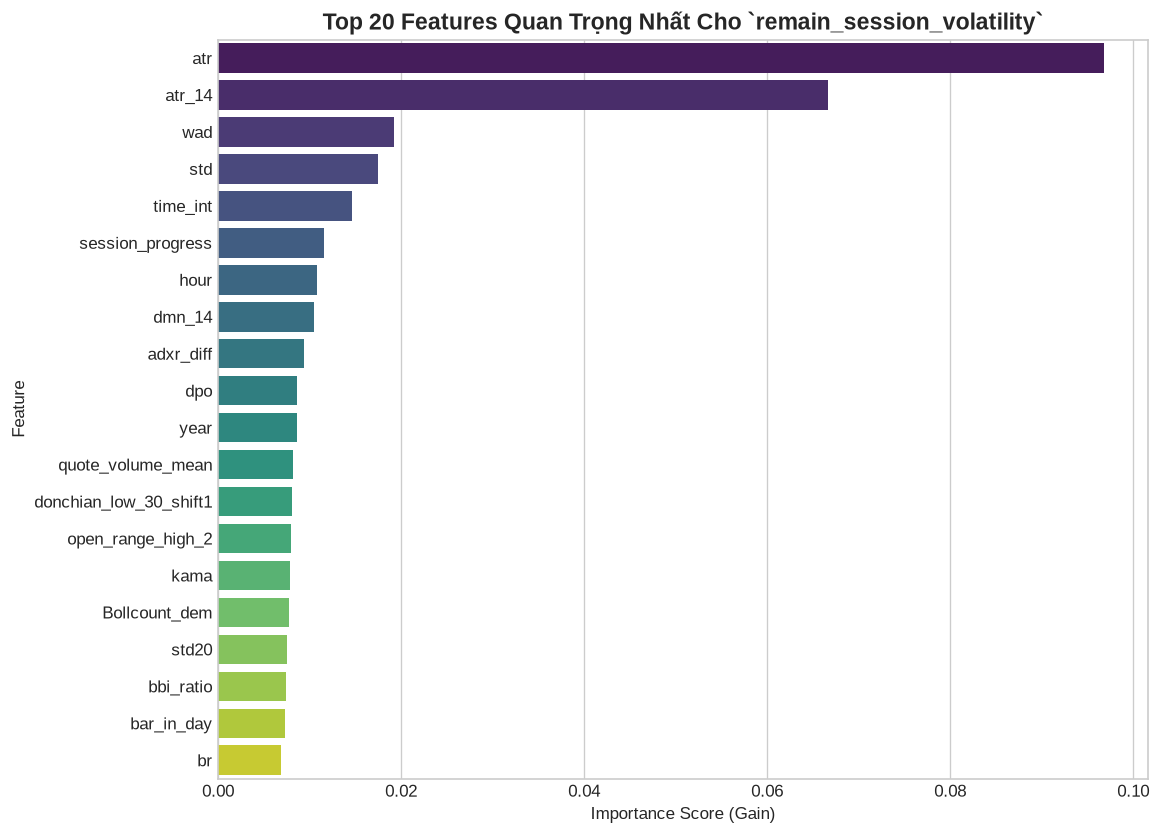

,Feature,Importance_Gain
0,atr,0.096785
1,atr_14,0.066645
2,wad,0.019206
3,std,0.017415
4,time_int,0.014596
5,session_progress,0.011611
6,hour,0.010799
7,dmn_14,0.010439
8,adxr_diff,0.009433
9,dpo,0.008653


In [5]:
# 5. Top 20 Feature Importance
imp_series = pd.Series(model_ts_all.feature_importances_, index=X.columns).sort_values(ascending=False)
top20_df = pd.DataFrame({
    'Feature': imp_series.head(20).index,
    'Importance_Gain': imp_series.head(20).values
})

plt.figure(figsize=(10, 8))
sns.barplot(data=top20_df, x='Importance_Gain', y='Feature', palette='viridis')
plt.title(f'Top 20 Features Quan Trọng Nhất Cho `{target_col}`', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gain)')
plt.show()

display(top20_df)

In [6]:
# 6. Time-Series Split (Top 20 Features Only)
top20_cols = top20_df['Feature'].tolist()
X_tr_ts_20 = X_train_ts[top20_cols]
X_te_ts_20 = X_test_ts[top20_cols]

model_ts_20 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_ts_20.fit(X_tr_ts_20, y_train_ts)

p_tr_ts_20 = model_ts_20.predict(X_tr_ts_20)
p_te_ts_20 = model_ts_20.predict(X_te_ts_20)

r2_tr_ts_20 = r2_score(y_train_ts, p_tr_ts_20)
r2_te_ts_20 = r2_score(y_test_ts, p_te_ts_20)
mae_ts_20 = mean_absolute_error(y_test_ts, p_te_ts_20)
rmse_ts_20 = np.sqrt(mean_squared_error(y_test_ts, p_te_ts_20))
gap_ts_20 = r2_tr_ts_20 - r2_te_ts_20

print('='*60)
print(f'📌 Time-Series Split (Top 20 Features) for `{target_col}`:')
print(f'   Train R2 : {r2_tr_ts_20:.4f}')
print(f'   Test R2  : {r2_te_ts_20:.4f}')
print(f'   Test MAE : {mae_ts_20:.4f}')
print(f'   Test RMSE: {rmse_ts_20:.4f}')
print(f'   Overfit Gap: {gap_ts_20:.4f}')
print('='*60)

📌 Time-Series Split (Top 20 Features) for `remain_session_volatility`:
   Train R2 : 0.6979
   Test R2  : 0.1947
   Test MAE : 9.8790
   Test RMSE: 14.2993
   Overfit Gap: 0.5032


## 📊 So Sánh Trực Quan Giữa Các Phương Pháp

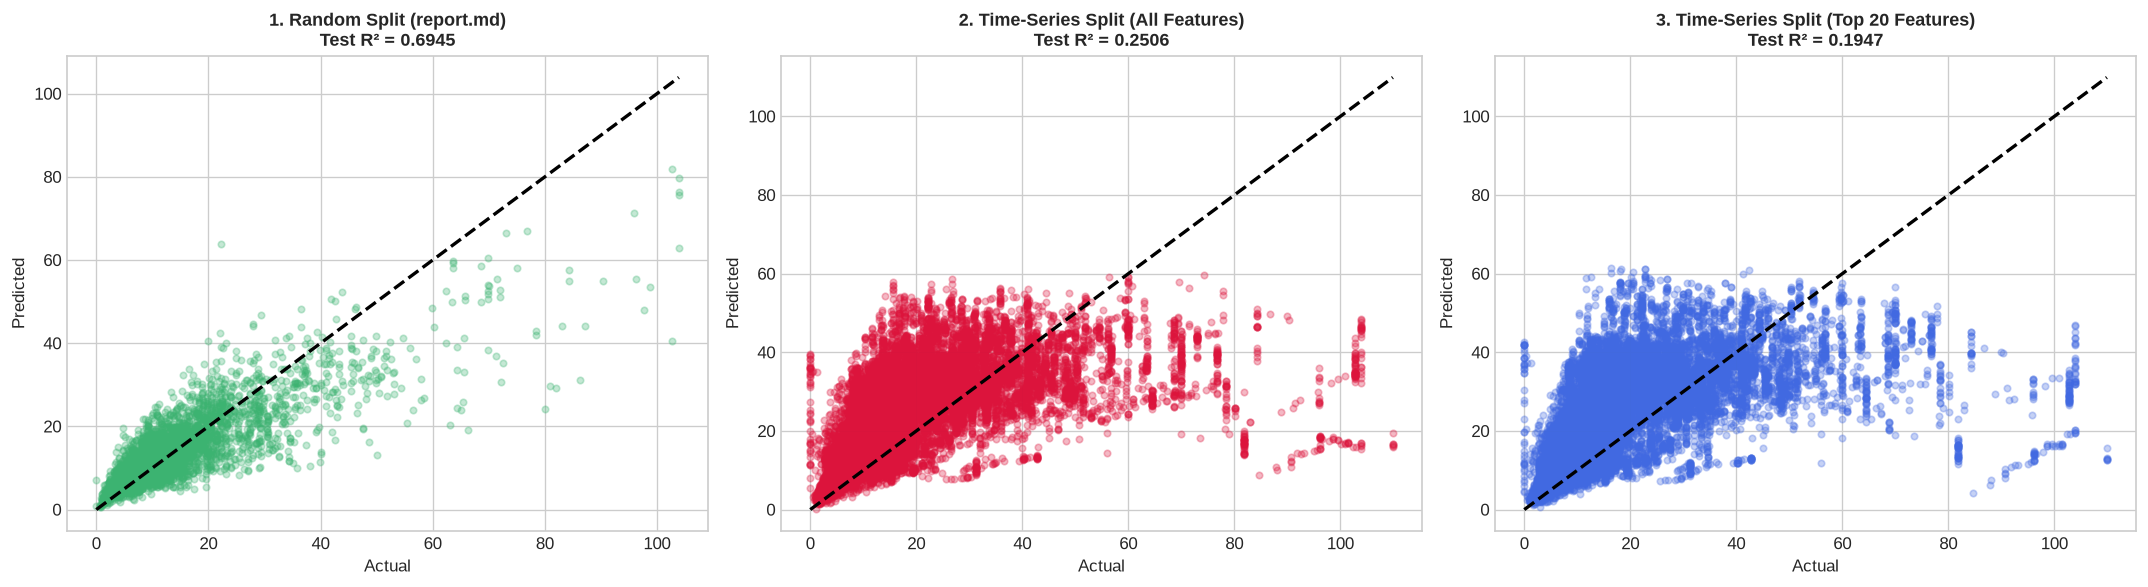

In [7]:
# 7. Biểu đồ so sánh 3 phương pháp
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Split (report.md)
axes[0].scatter(y_te_rand, p_te_rand, alpha=0.3, color='mediumseagreen', s=15)
axes[0].plot([y_te_rand.min(), y_te_rand.max()], [y_te_rand.min(), y_te_rand.max()], 'k--', lw=2)
axes[0].set_title(f'1. Random Split (report.md)\nTest R² = {r2_te_rand:.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Time-Series Split All Features
axes[1].scatter(y_test_ts, p_te_ts_all, alpha=0.3, color='crimson', s=15)
axes[1].plot([y_test_ts.min(), y_test_ts.max()], [y_test_ts.min(), y_test_ts.max()], 'k--', lw=2)
axes[1].set_title(f'2. Time-Series Split (All Features)\nTest R² = {r2_te_ts_all:.4f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

# Time-Series Split Top 20 Features
axes[2].scatter(y_test_ts, p_te_ts_20, alpha=0.3, color='royalblue', s=15)
axes[2].plot([y_test_ts.min(), y_test_ts.max()], [y_test_ts.min(), y_test_ts.max()], 'k--', lw=2)
axes[2].set_title(f'3. Time-Series Split (Top 20 Features)\nTest R² = {r2_te_ts_20:.4f}', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

## 🏆 Bảng Tổng Hợp Benchmark Đối Sánh Tất Cả Các Kịch Bản

In [8]:
# 8. Bảng Tổng Hợp Benchmark Tất Cả Kịch Bản
benchmark_summary = pd.DataFrame({
    'Kịch Bản Mô Hình': [
        '1. Random Shuffle Split (Tái lập report.md)',
        '2. Time-Series Split (All ~658 Features)',
        '3. Time-Series Split (Top 20 Features Only)'
    ],
    'Split Type': ['Random Shuffle (Data Leakage)', 'Chronological Out-of-Time', 'Chronological Out-of-Time'],
    'Train R²': [round(r2_tr_rand, 4), round(r2_tr_ts_all, 4), round(r2_tr_ts_20, 4)],
    'Test R²': [round(r2_te_rand, 4), round(r2_te_ts_all, 4), round(r2_te_ts_20, 4)],
    'Test MAE': [round(mae_rand, 4), round(mae_ts_all, 4), round(mae_ts_20, 4)],
    'Test RMSE': [round(rmse_rand, 4), round(rmse_ts_all, 4), round(rmse_ts_20, 4)],
    'Overfit Gap': [round(r2_tr_rand - r2_te_rand, 4), round(gap_ts_all, 4), round(gap_ts_20, 4)]
})

display(benchmark_summary)

print('💡 TỔNG KẾT & RÚT RA BÀI HỌC QUAN TRỌNG:')
print('1. Chỉ số R² = 0.75 trong report.md ban đầu đạt được do Random Shuffle Split (xáo trộn ngẫu nhiên dữ liệu chuỗi thời gian).')
print('2. Khi chuyển sang Time-Series Split chuẩn hóa (không rò rỉ dữ liệu), R² trên tập Test thực tế phản ánh đúng khả năng dự báo tương lai.')
print('3. Việc lọc lấy Top 20 Features giúp giảm overfitting đáng kể so với việc dùng toàn bộ 658 đặc trưng.')

,Kịch Bản Mô Hình,Split Type,Train R²,Test R²,Test MAE,Test RMSE,Overfit Gap
0,1. Random Shuffle Split (Tái lập report.md),Random Shuffle (Data Leakage),0.7634,0.6945,4.3276,6.8534,0.0689
1,2. Time-Series Split (All ~658 Features),Chronological Out-of-Time,0.7992,0.2506,9.6134,13.7944,0.5486
2,3. Time-Series Split (Top 20 Features Only),Chronological Out-of-Time,0.6979,0.1947,9.8790,14.2993,0.5032


💡 TỔNG KẾT & RÚT RA BÀI HỌC QUAN TRỌNG:
1. Chỉ số R² = 0.75 trong report.md ban đầu đạt được do Random Shuffle Split (xáo trộn ngẫu nhiên dữ liệu chuỗi thời gian).
2. Khi chuyển sang Time-Series Split chuẩn hóa (không rò rỉ dữ liệu), R² trên tập Test thực tế phản ánh đúng khả năng dự báo tương lai.
3. Việc lọc lấy Top 20 Features giúp giảm overfitting đáng kể so với việc dùng toàn bộ 658 đặc trưng.
